# Target-Verteilung der MixUp-Variante

Dieses Notebook visualisiert die Target-Verteilung des standardmäßigen MixUp-Verfahrens.

Dieses Verfahren schneidet **zusammenhängende Slices** aus den Texten aus und mischt sie. Die Start- und End-Bereiche werden völlig unabhängig für Leichte Sprache (LS) und Alltagssprache (AS) gewählt.
Das Target wird über das Verhältnis der Zeichenanzahl des LS-Teils zur Gesamtzeichenanzahl des gemischten Absatzes berechnet.

In [1]:
import pandas as pd
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import os

# Configuration
CSV_PATH = "../results/information_loss_analysis_cleaned.csv"
MIN_SIM = 0.8
MAX_SIM = 0.98

# Daten laden
df = pd.read_csv(CSV_PATH)
mask = (df["semantic_similarity_8192"] >= MIN_SIM) & (df["semantic_similarity_8192"] <= MAX_SIM)
df_filtered = df[mask].dropna(subset=["ls_text", "as_text"])
print(f"Gefundene Artikelpaare: {len(df_filtered)}")

# Spacy für schnelles Satz-Splitting (Sentencizer) vorbereiten
nlp = spacy.blank("de")
nlp.add_pipe("sentencizer")

Gefundene Artikelpaare: 1032


## 2. Dataset Klasse definieren

In [2]:
class MixupDataset(Dataset):
    def __init__(self, df, nlp_sentencizer):
        self.ls_data = []
        self.as_data = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Segmentiere"):
            ls_sents = [s.text.strip() for s in nlp_sentencizer(str(row["ls_text"])).sents if s.text.strip()]
            as_sents = [s.text.strip() for s in nlp_sentencizer(str(row["as_text"])).sents if s.text.strip()]
            self.ls_data.append(ls_sents)
            self.as_data.append(as_sents)
            
    def __len__(self):
        return len(self.ls_data)
        
    def __getitem__(self, idx):
        leichte_saetze = self.ls_data[idx]
        alltags_saetze = self.as_data[idx]
        
        num_leicht = len(leichte_saetze)
        num_alltag = len(alltags_saetze)
        
        if num_leicht == 0 or num_alltag == 0:
            return "", 0.5
            
        start_leichte_saetze, ende_leichte_saetze = sorted([random.randint(0, num_leicht), random.randint(0, num_leicht)])
        sample_leicht = leichte_saetze[start_leichte_saetze:ende_leichte_saetze]
        
        start_alltags_saetze, ende_alltags_saetze = sorted([random.randint(0, num_alltag), random.randint(0, num_alltag)])
        sample_alltag = alltags_saetze[start_alltags_saetze:ende_alltags_saetze]
        
        kompletter_absatz = sample_leicht + sample_alltag
        random.shuffle(kompletter_absatz)
        
        str_sample_leicht = ''.join(sample_leicht)
        str_sample_alltag = ''.join(sample_alltag)
        len_sample_leicht = len(str_sample_leicht)
        len_sample_alltag = len(str_sample_alltag)
        
        total_len = len_sample_leicht + len_sample_alltag
        regression_target = len_sample_leicht / total_len if total_len > 0 else 0.5
        
        return ' '.join(kompletter_absatz), regression_target

mixup_ds = MixupDataset(df_filtered, nlp)

Segmentiere:   0%|          | 0/1032 [00:00<?, ?it/s]

## 3. Beispiel-Absatz ausgeben

In [3]:
print("="*80)
print("BEISPIEL EINES ZUSAMMENGESTELLTEN ABSATZES (MixupDataset)")
print("="*80)
found_example = False
for i in range(len(mixup_ds)):
    leichte_saetze = mixup_ds.ls_data[i]
    alltags_saetze = mixup_ds.as_data[i]
    if len(leichte_saetze) >= 5 and len(alltags_saetze) >= 5:
        start_l, end_l = sorted([random.randint(0, len(leichte_saetze)), random.randint(0, len(leichte_saetze))])
        sample_l = leichte_saetze[start_l:end_l]
        
        start_a, end_a = sorted([random.randint(0, len(alltags_saetze)), random.randint(0, len(alltags_saetze))])
        sample_a = alltags_saetze[start_a:end_a]
        
        if len(sample_l) > 0 and len(sample_a) > 0:
            labeled_sents = [(s, "LS") for s in sample_l] + [(s, "AS") for s in sample_a]
            random.shuffle(labeled_sents)
            
            shuffled_text = " ".join([s[0] for s in labeled_sents])
            len_l = len("".join(sample_l))
            len_a = len("".join(sample_a))
            total_len = len_l + len_a
            target = len_l / total_len if total_len > 0 else 0.5
            
            print(f"LS-Sätze (Extrakt, n={len(sample_l)}):")
            for s in sample_l:
                print(f"  - {s}")
            print(f"\nAS-Sätze (Extrakt, n={len(sample_a)}):")
            for s in sample_a:
                print(f"  - {s}")
            print(f"\nZusammengestellter Absatz:")
            print(f"  {shuffled_text}")
            print(f"\nSatz-Herkunft (Visualisiert):")
            vis = " ".join([f"[{tag}] {s}" for s, tag in labeled_sents])
            print(f"  {vis}")
            print(f"\nRegression Target (Zeichen-Verhältnis): {target:.4f}")
            print("="*80 + "\n")
            found_example = True
            break
if not found_example:
    print("Kein passendes Artikelpaar gefunden.")
    print("="*80 + "\n")

BEISPIEL EINES ZUSAMMENGESTELLTEN ABSATZES (MixupDataset)
LS-Sätze (Extrakt, n=8):
  - Inhaltsverzeichnis Video: Was macht der Behindertenbeauftragte der Bundesregierung?
  - Gesetzlicher Auftrag Politisch und sozial mitgestalten Informieren – Beraten – Öffentlichkeitsarbeit leisten – Inklusions-Gedanken verbreiten Grenzen der Beratung Video: Was macht der Behindertenbeauftragte der Bundesregierung?
  - Video: Was macht der Behindertenbeauftragte der Bundesregierung?
  - zum Download: Video: Was macht der Behindertenbeauftragte der Bundesregierung?
  - (307 MB, 02:39) Gesetzlicher Auftrag Der oder die Behindertenbeauftragte wird von der Bundes-Regierung ausgewählt.
  - Für eine Legislatur-Periode.
  - Die Legislatur-Periode ist die Zeit zwischen zwei Wahlen.
  - In Deutschland dauert die Legislatur-Periode normalerweise 4 Jahre.

AS-Sätze (Extrakt, n=2):
  - Das Amt des Beauftragten der Bundesregierung für die Belange von Menschen mit Behinderungen umfasst vielfältige Aufgaben.
  - Erf

## 4. Simulation & Target-Erfassung

In [4]:
targets = []

EPOCHS = 10
for epoch in range(EPOCHS):
    for i in range(len(df_filtered)):
        _, t = mixup_ds[i]
        targets.append(t)

print(f"Simulation beendet. {len(targets)} Samples generiert.")

Simulation beendet. 10320 Samples generiert.


## 5. Visualisierung der Target-Verteilung

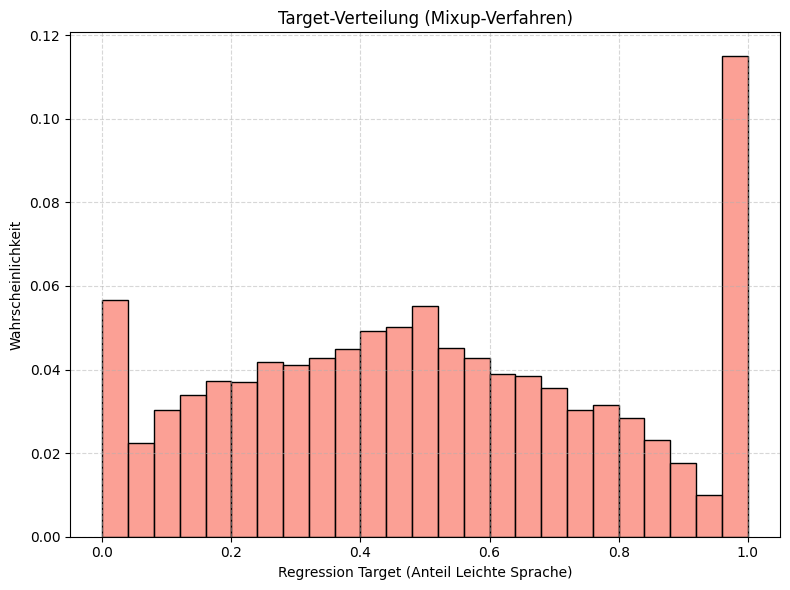

In [5]:
plt.figure(figsize=(8, 6))

sns.histplot(targets, bins=25, kde=False, color="salmon", stat="probability")
plt.title("Target-Verteilung (Mixup-Verfahren)")
plt.xlabel("Regression Target (Anteil Leichte Sprache)")
plt.ylabel("Wahrscheinlichkeit")
plt.xlim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Vorbereitung für das BiLSTM-Regressions-Training

Hier teilen wir die bereinigten Daten in Training (90%) und Validierung (10%) auf, erstellen das Vokabular auf Basis der Trainingsdaten und definieren eine angepasste `MixupPyTorchDataset`-Klasse für PyTorch.

In [6]:
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

# 1. Train-Val Split
train_df, val_df = train_test_split(df_filtered, test_size=0.1, random_state=42)
print(f"Training Artikelpaare: {len(train_df)}, Validierung Artikelpaare: {len(val_df)}")

# 2. Vokabular-Klasse definieren
class Vocab:
    def __init__(self, token_list, max_size=20000, min_freq=2):
        counter = Counter(token_list)
        self.itos = ["<pad>", "<unk>"]
        self.stoi = {"<pad>": 0, "<unk>": 1}
        for token, freq in counter.most_common(max_size):
            if freq >= min_freq:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)
                
    def __len__(self):
        return len(self.itos)
    
    def encode(self, tokens):
        return [self.stoi.get(t, self.stoi["<unk>"]) for t in tokens]

# Vokabular aufbauen
print("Sammle Tokens für das Vokabular...")
all_train_tokens = []
# Wir nutzen denselben blanken Spacy-Tokenizer für Konsistenz
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Vokab-Tokens sammeln"):
    for text in [str(row["ls_text"]), str(row["as_text"])]:
        doc = nlp(text)
        for token in doc:
            if not token.is_space:
                all_train_tokens.append(token.text.lower())

vocab = Vocab(all_train_tokens, max_size=25000, min_freq=2)
print(f"Vokabular-Größe: {len(vocab)}")

# 3. PyTorch-kompatible Mixup-Dataset-Klasse (Deterministisch & Prä-generiert)
class MixupPyTorchDataset(Dataset):
    def __init__(self, df, vocab, nlp_sentencizer, max_seq_len=150, mixtures_per_pair=5, is_train=True):
        self.vocab = vocab
        self.max_seq_len = max_seq_len
        self.samples = []
        
        # Seed festlegen für Konsistenz und Reproduzierbarkeit
        seed = 42 if is_train else 99
        random.seed(seed)
        
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Segmentiere & Tokenisiere"):
            ls_doc = nlp_sentencizer(str(row["ls_text"]))
            as_doc = nlp_sentencizer(str(row["as_text"]))
            
            ls_sents = []
            for sent in ls_doc.sents:
                text = sent.text.strip()
                tokens = [t.text.lower() for t in sent if not t.is_space]
                if len(tokens) > 0:
                    ls_sents.append((tokens, len(text)))
                    
            as_sents = []
            for sent in as_doc.sents:
                text = sent.text.strip()
                tokens = [t.text.lower() for t in sent if not t.is_space]
                if len(tokens) > 0:
                    as_sents.append((tokens, len(text)))
                    
            num_leicht = len(ls_sents)
            num_alltag = len(as_sents)
            
            if num_leicht == 0 or num_alltag == 0:
                continue
                
            # Prä-generiere feste Mischungen pro Artikelpaar
            for _ in range(mixtures_per_pair):
                start_l, end_l = sorted([random.randint(0, num_leicht), random.randint(0, num_leicht)])
                sample_l = ls_sents[start_l:end_l]
                
                start_a, end_a = sorted([random.randint(0, num_alltag), random.randint(0, num_alltag)])
                sample_a = as_sents[start_a:end_a]
                
                if len(sample_l) == 0 and len(sample_a) == 0:
                    continue
                    
                # Target: Verhältnis der Zeichenlängen
                char_len_l = sum(item[1] for item in sample_l)
                char_len_a = sum(item[1] for item in sample_a)
                total_char_len = char_len_l + char_len_a
                regression_target = char_len_l / total_char_len if total_char_len > 0 else 0.5
                
                # Sätze mischen und flatten
                mixed_sentences = [item[0] for item in sample_l] + [item[0] for item in sample_a]
                random.shuffle(mixed_sentences)
                
                flat_tokens = [token for sent in mixed_sentences for token in sent]
                encoded = self.vocab.encode(flat_tokens)
                
                if len(encoded) > self.max_seq_len:
                    encoded = encoded[:self.max_seq_len]
                else:
                    encoded = encoded + [0] * (self.max_seq_len - len(encoded))
                    
                self.samples.append((encoded, regression_target))
                
        print(f"Generiert: {len(self.samples)} Samples.")
            
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        encoded, target = self.samples[idx]
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(target, dtype=torch.float)

# Datasets instanziieren (Trainingsdaten augmentieren, Validierung deterministisch halten)
print("Erstelle PyTorch Datasets...")
train_dataset = MixupPyTorchDataset(train_df, vocab, nlp, max_seq_len=150, mixtures_per_pair=10, is_train=True)
val_dataset = MixupPyTorchDataset(val_df, vocab, nlp, max_seq_len=150, mixtures_per_pair=2, is_train=False)


Training Artikelpaare: 928, Validierung Artikelpaare: 104
Sammle Tokens für das Vokabular...


Vokab-Tokens sammeln:   0%|          | 0/928 [00:00<?, ?it/s]

Vokabular-Größe: 11006
Erstelle PyTorch Datasets...


Segmentiere & Tokenisiere:   0%|          | 0/928 [00:00<?, ?it/s]

Generiert: 9205 Samples.


Segmentiere & Tokenisiere:   0%|          | 0/104 [00:00<?, ?it/s]

Generiert: 206 Samples.


## 7. Modelldefinition (BiLSTM Regressor)

Wir definieren einen BiLSTM-Regressor zur Vorhersage von $\lambda$. Da $\lambda$ ein kontinuierlicher Wert zwischen 0 und 1 ist, verwenden wir am Ende ein lineares Layer mit einer anschließenden Sigmoid-Aktivierungsfunktion.

In [7]:
import torch.nn as nn

class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

## 8. Training des Regressionsmodells

Wir trainieren das Modell mit dem AdamW Optimizer und MSE-Loss (Mean Squared Error). Wir führen Early Stopping auf Basis des Validierungs-Loss ein.

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Hyperparameter
BATCH_SIZE = 64
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
EPOCHS = 40
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Nutze Device: {DEVICE}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = BiLSTMRegressor(len(vocab), EMBEDDING_DIM, HIDDEN_DIM).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR)
criterion = nn.MSELoss()

history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_loss = float('inf')
patience = 5
counter = 0

# Verzeichnis für Ergebnisse erstellen falls nicht vorhanden
os.makedirs("../results", exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        preds = model(batch_x).squeeze()
        
        # Sicherstellen, dass die Dimensionen übereinstimmen
        if preds.ndim == 0:
            preds = preds.unsqueeze(0)
            
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    # Validation
    model.eval()
    val_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            preds = model(batch_x).squeeze()
            if preds.ndim == 0:
                preds = preds.unsqueeze(0)
                
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
            
    epoch_train_loss = epoch_loss / len(train_loader)
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_mae = mean_absolute_error(all_targets, all_preds)
    
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_mae'].append(epoch_val_mae)
    
    print(f"Epoch {epoch+1:02d} | Train Loss (MSE): {epoch_train_loss:.4f} | Val Loss (MSE): {epoch_val_loss:.4f} | Val MAE: {epoch_val_mae:.4f}")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "../results/bilstm_mixup_regression_static.pt")
        print("=> Modell gespeichert (bester Val Loss)")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping ausgelöst.")
            break

Nutze Device: cpu


Epoch 1:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 01 | Train Loss (MSE): 0.0779 | Val Loss (MSE): 0.0806 | Val MAE: 0.2295
=> Modell gespeichert (bester Val Loss)


Epoch 2:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 02 | Train Loss (MSE): 0.0652 | Val Loss (MSE): 0.0768 | Val MAE: 0.2341
=> Modell gespeichert (bester Val Loss)


...

Epoch 22 | Train Loss (MSE): 0.0069 | Val Loss (MSE): 0.0300 | Val MAE: 0.1161


Epoch 23:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 23 | Train Loss (MSE): 0.0065 | Val Loss (MSE): 0.0289 | Val MAE: 0.1153


Epoch 24:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 24 | Train Loss (MSE): 0.0064 | Val Loss (MSE): 0.0297 | Val MAE: 0.1191
Early Stopping ausgelöst.


## 9. Auswertung und Visualisierung des Trainingsverlaufs

Hier visualisieren wir den Trainingsverlauf des Regressionsmodells (MSE über die Epochen) und vergleichen die echten Targets mit den vorhergesagten Werten der Validierungsdaten.

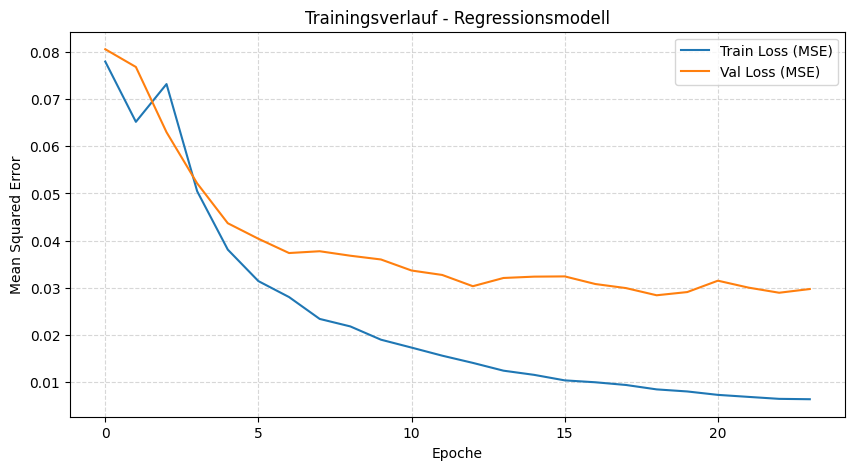

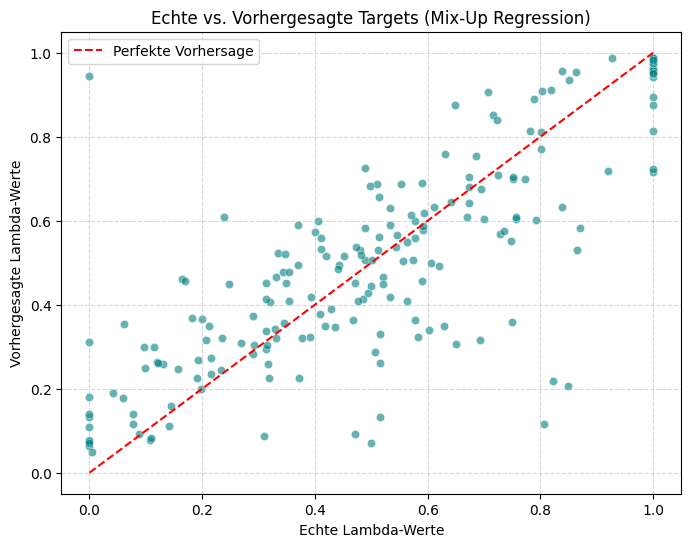

Abschließende Validierungsmetriken des besten Modells:
- Mean Squared Error (MSE): 0.0297
- Mean Absolute Error (MAE): 0.1170


In [9]:
# 1. Loss Plotten
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss (MSE)')
plt.plot(history['val_loss'], label='Val Loss (MSE)')
plt.title('Trainingsverlauf - Regressionsmodell')
plt.xlabel('Epoche')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 2. Scatterplot: True vs Predicted
model.load_state_dict(torch.load("../results/bilstm_mixup_regression_static.pt"))
model.eval()
val_preds = []
val_targets = []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        batch_x = batch_x.to(DEVICE)
        preds = model(batch_x).squeeze()
        if preds.ndim == 0:
            preds = preds.unsqueeze(0)
        val_preds.extend(preds.cpu().numpy())
        val_targets.extend(batch_y.numpy())

plt.figure(figsize=(8, 6))
sns.scatterplot(x=val_targets, y=val_preds, alpha=0.6, color="teal")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Perfekte Vorhersage")
plt.title("Echte vs. Vorhergesagte Targets (Mix-Up Regression)")
plt.xlabel("Echte Lambda-Werte")
plt.ylabel("Vorhergesagte Lambda-Werte")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Metriken ausgeben
val_mse = mean_squared_error(val_targets, val_preds)
val_mae = mean_absolute_error(val_targets, val_preds)
print(f"Abschließende Validierungsmetriken des besten Modells:")
print(f"- Mean Squared Error (MSE): {val_mse:.4f}")
print(f"- Mean Absolute Error (MAE): {val_mae:.4f}")